# Knowledge Intelligence System — Production Pipeline

End-to-end RAG pipeline with:
- Multi-format document ingestion (PDF, TXT, MD)
- Chroma vector store with HuggingFace embeddings
- Groq LLM (`llama-3.1-70b-versatile`) with conversation memory
- MongoDB metadata & query history
- MLflow / DagsHub experiment tracking
- Checkpoint, export and ZIP download

**Required Colab Secrets:** `GROQ_API_KEY`, `MONGO_DB_URL`,
`MLFLOW_TRACKING_URI`, `MLFLOW_TRACKING_USERNAME`, `MLFLOW_TRACKING_PASSWORD`



📷 DISPLAYING: /content/architecture 2.png


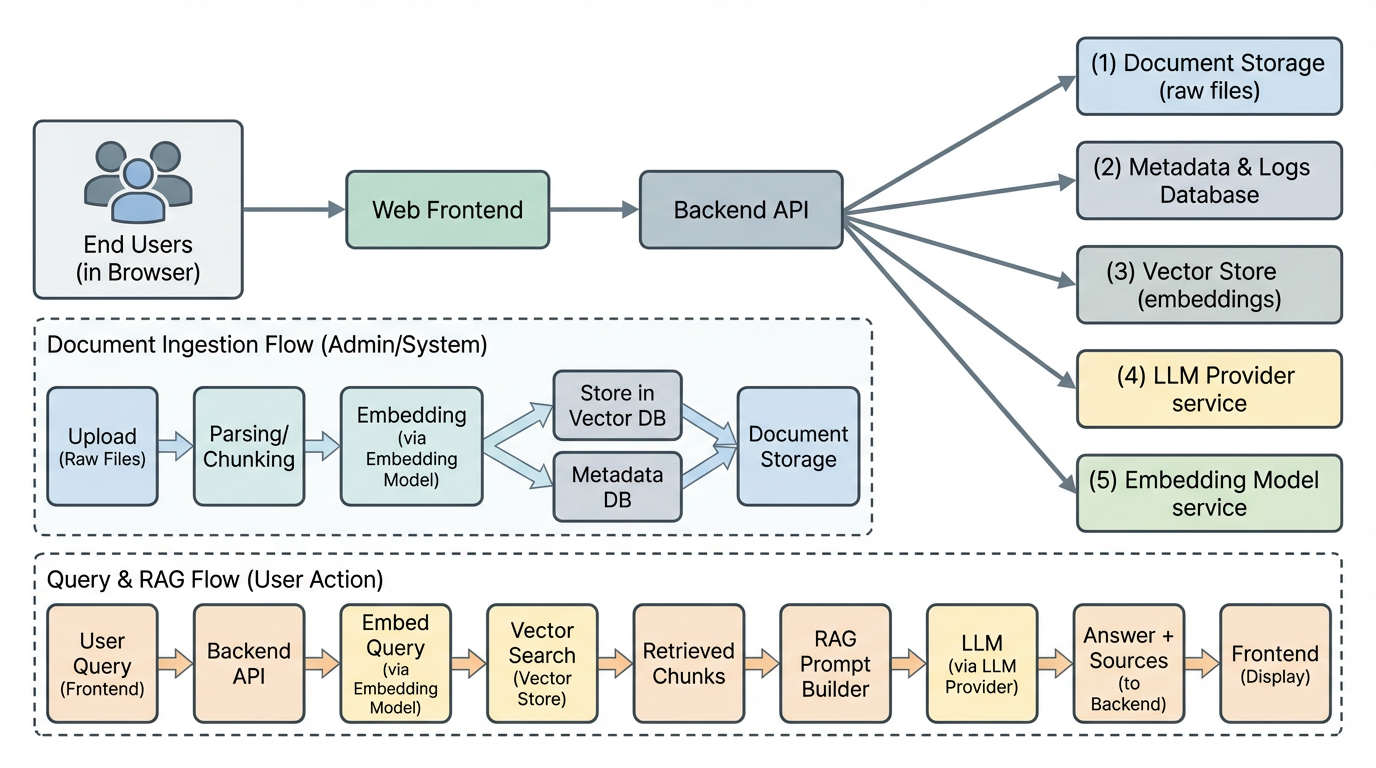


📷 DISPLAYING: /content/architecture.png


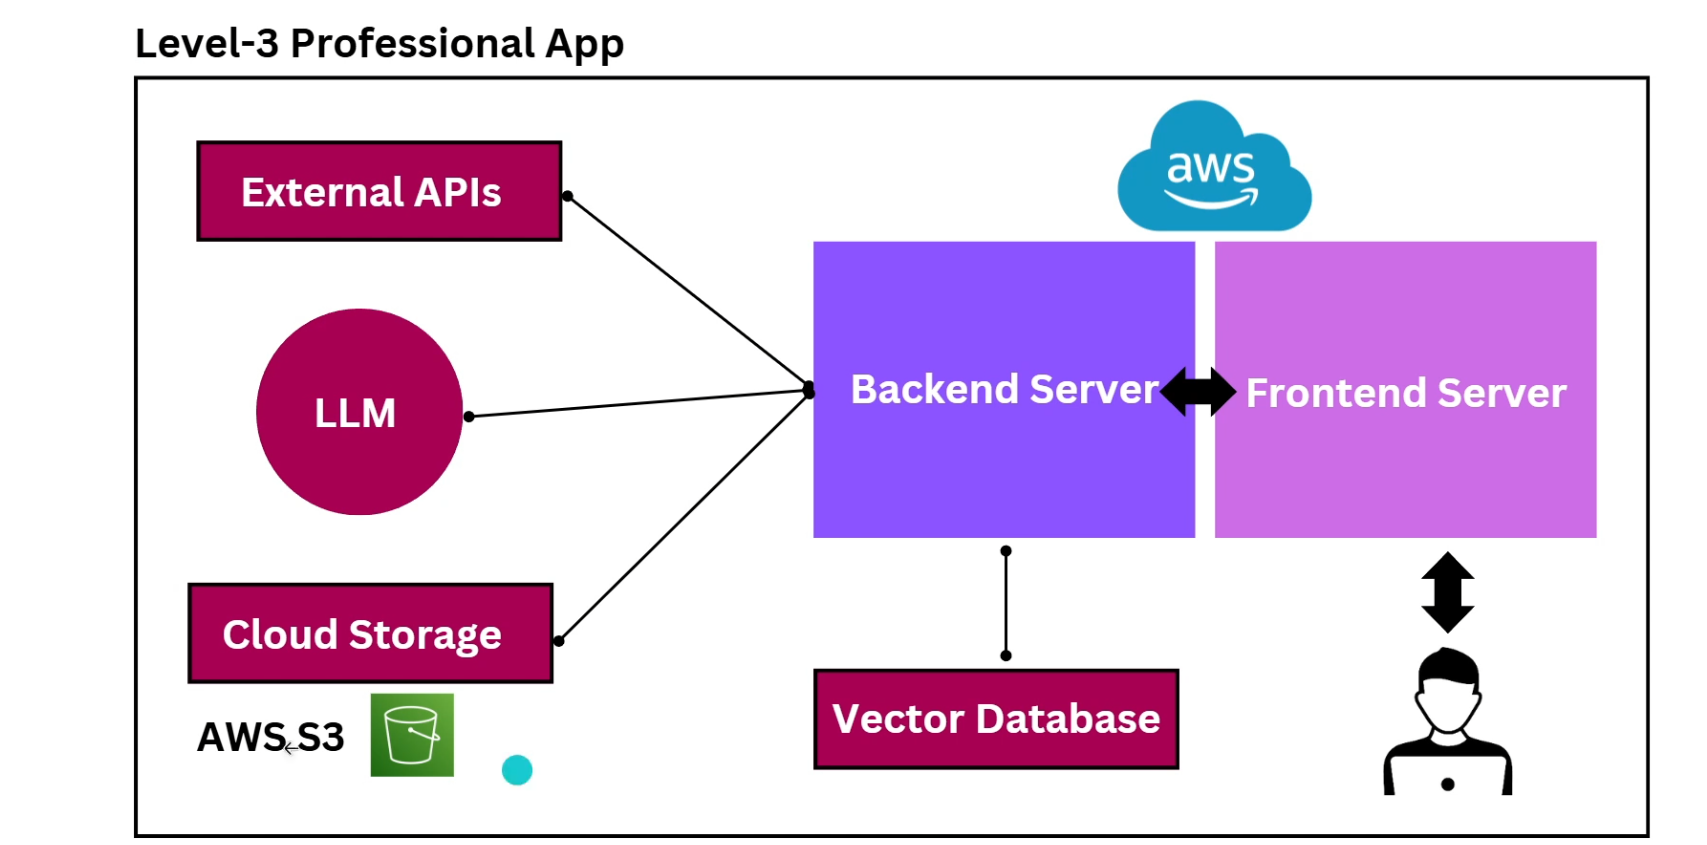

In [34]:
from IPython.display import Image, display
from pathlib import Path

image_paths = [
    "/content/architecture 2.png",
    "/content/architecture.png"
]

for img_path in image_paths:

    print(f"\n📷 DISPLAYING: {img_path}")

    if Path(img_path).exists():

        display(Image(filename=img_path))

    else:

        print("❌ File not found")

## Phase 0 — Environment Variables & Secret Loading
Load all credentials from Colab Secrets, configure MLflow backend.

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 0 · ENVIRONMENT VARIABLES & SECRET LOADING
# ════════════════════════════════════════════════════════════════════════════

import os, sys
from pathlib import Path

# ── Detect runtime ───────────────────────────────────────────────────────────
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('⚠️  Not in Colab — falling back to local env vars.')

def _get(key: str, fallback: str = '') -> str:
    """Fetch secret from Colab Secrets or os.environ."""
    if IN_COLAB:
        try:
            return userdata.get(key) or fallback
        except Exception:
            return os.getenv(key, fallback)
    return os.getenv(key, fallback)

# ── MongoDB ──────────────────────────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = _get('MONGO_DB_URL')

# ── Groq ─────────────────────────────────────────────────────────────────────
os.environ['GROQ_API_KEY'] = _get('GROQ_API_KEY')

# ── MLflow / DagsHub ─────────────────────────────────────────────────────────
USE_DAGSHUB = True  # ✅ set False to use local file-based MLflow

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = _get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = _get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = _get('MLFLOW_TRACKING_PASSWORD')
else:
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ.get('MLFLOW_TRACKING_URI', 'not set')}")
print(f"   GROQ_API_KEY        = {'set ✓' if os.environ.get('GROQ_API_KEY') else 'MISSING ✗'}")
print(f"   MONGO_DB_URL        = {'set ✓' if os.environ.get('MONGO_DB_URL') else 'MISSING ✗'}")


✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow
   GROQ_API_KEY        = set ✓
   MONGO_DB_URL        = set ✓


## Phase 1 — Dependencies
Install all required packages (LangChain ≥ 1.2, Groq, Chroma, MLflow, etc.).

In [17]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 · DEPENDENCY INSTALLATION
# ════════════════════════════════════════════════════════════════════════════

import subprocess
import sys

PACKAGES = [
    'langchain',
    'langchain-core',
    'langchain-community',
    'langchain-groq',
    'langchain-chroma',
    'langchain-text-splitters',
    'chromadb',
    'sentence-transformers',
    'pymongo',
    'pypdf',
    'mlflow',
    'pydantic',
    'pandas',
    'numpy',
    'tqdm',
    'faiss-cpu' # Added faiss-cpu for vector store functionality
]

print('📦 Installing dependencies ...')
for pkg in PACKAGES:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', pkg], # Added --upgrade to ensure latest versions
        capture_output=True, text=True
    )
    status = '✅' if result.returncode == 0 else '⚠️ '
    print(f'   {status} {pkg}')

print('\n✅ All packages installed.')

📦 Installing dependencies ...
   ✅ langchain
   ✅ langchain-core
   ✅ langchain-community
   ✅ langchain-groq
   ✅ langchain-chroma
   ✅ langchain-text-splitters
   ✅ chromadb
   ✅ sentence-transformers
   ✅ pymongo
   ✅ pypdf
   ✅ mlflow
   ✅ pydantic
   ✅ pandas
   ✅ numpy
   ✅ tqdm
   ✅ faiss-cpu

✅ All packages installed.


## Phase 2 — Configuration & Logging
Centralised `SystemConfig` dataclass and production-grade coloured logger.

In [18]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 3 · FREE VECTOR STORE (FAISS - LOCAL & FREE)
# ════════════════════════════════════════════════════════════════════════════

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

from typing import List, Dict
from datetime import datetime
import os
import pickle


## Phase 3 — Vector Store (Chroma + HuggingFace)
Persistent semantic index with batched ingestion and similarity search.

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 4 · DOCUMENT PROCESSOR
# ════════════════════════════════════════════════════════════════════════════

from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path
from typing import List


## Phase 4 — Document Processor
Load PDF / TXT / MD files and split into overlapping chunks.

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 5 · LLM SERVICE (LANGCHAIN 1.2+ COMPATIBLE)
# ════════════════════════════════════════════════════════════════════════════

import time
from typing import Dict, Any
from datetime import datetime

from langchain_groq import ChatGroq

from langchain_core.prompts import (
    ChatPromptTemplate,
    MessagesPlaceholder
)

from langchain_core.runnables import (
    RunnablePassthrough,
    RunnableLambda
)
from langchain_core.output_parsers import StrOutputParser

from langchain_core.messages import (
    HumanMessage,
    AIMessage
)


## Phase 5 — LLM Service (Groq + RAG)
Conversational RAG chain using `llama-3.1-70b-versatile`. Token budget is respected via `max_tokens=512`.

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 6 · MONGODB INTEGRATION
# ════════════════════════════════════════════════════════════════════════════

from pymongo import MongoClient
from pymongo.errors import ServerSelectionTimeoutError
from datetime import datetime
from typing import Dict


## Phase 6 — MongoDB Integration
Store document metadata, query history (30-day TTL) and system events (7-day TTL).

In [23]:
import os
from pymongo import MongoClient
from pymongo.errors import ServerSelectionTimeoutError
from datetime import datetime
from typing import Dict, Any
from dataclasses import dataclass, asdict

# Placeholder for a logger function, as it's used but not defined in this context
def get_logger(name):
    import logging
    logging.basicConfig(level=logging.INFO)
    return logging.getLogger(name)

@dataclass
class SystemConfig:
    vector_db_path  : str   = "vector_db"
    mongo_db_url    : str   = ""
    groq_api_key    : str   = ""
    model_name      : str   = "llama-3.1-8b-instant"
    embedding_model : str   = "sentence-transformers/all-MiniLM-L6-v2"
    chunk_size      : int   = 1000
    chunk_overlap   : int   = 200
    similarity_k    : int   = 4
    temperature     : float = 0.7
    max_tokens      : int   = 512

    @classmethod
    def from_env(cls):
        return cls(
            vector_db_path=os.getenv("VECTOR_DB_PATH", "vector_db"),
            mongo_db_url=os.getenv("MONGO_DB_URL", ""),
            groq_api_key=os.getenv("GROQ_API_KEY", ""),
        )

    def safe_dict(self) -> Dict[str, Any]:
        d = asdict(self)
        for k in ("groq_api_key", "mongo_db_url"):
            if d[k]: d[k] = d[k][:8] + "***"
        return d

# Instantiate the configuration
cfg = SystemConfig.from_env()

class MongoService:
    """MongoDB wrapper for metadata and audit storage.

    Collections
    -----------
    documents   : metadata per ingested file (unique index on filename)
    queries     : question + answer history (TTL 30 days)
    system_logs : operational events       (TTL  7 days)

    All operations degrade gracefully when MongoDB is unavailable
    so the rest of the pipeline continues in offline mode.
    """

    def __init__(self, url: str, db_name: str = 'knowledge_system'):
        self._log = get_logger(f'{__name__}.Mongo')
        self._db = None
        if not url:
            self._log.warning('MONGO_DB_URL not set — offline mode')
            return
        try:
            client = MongoClient(url, serverSelectionTimeoutMS=4000)
            client.admin.command('ismaster')
            self._db = client[db_name]
            self._ensure_indexes()
            self._log.info('✅ MongoDB connected (%s)', db_name)
        except ServerSelectionTimeoutError:
            self._log.warning('MongoDB unreachable — offline mode')
        except Exception as e:
            self._log.warning('MongoDB error: %s — offline mode', e)

    def _ensure_indexes(self):
        try:
            self._db.documents.create_index('filename', unique=True)
            self._db.queries.create_index('ts', expireAfterSeconds=2_592_000)
            self._db.system_logs.create_index('ts', expireAfterSeconds=604_800)
        except Exception as e:
            self._log.debug('Index note: %s', e)

    # ── write helpers ─────────────────────────────────────────────────────────
    def save_doc_meta(self, filename: str, meta: Dict) -> bool:
        """Upsert document metadata."""
        if not self._db: return False
        try:
            self._db.documents.update_one(
                {'filename': filename},
                {'$set': {**meta, 'filename': filename,
                          'ts': datetime.now().isoformat()}},
                upsert=True,
            )
            return True
        except Exception as e:
            self._log.error('save_doc_meta: %s', e)
            return False

    def save_query(self, question: str, answer: str, model: str, dur: float) -> bool:
        """Append query record."""
        if not self._db: return False
        try:
            self._db.queries.insert_one({
                'question': question, 'answer': answer[:1000],
                'model': model, 'duration_s': dur,
                'ts': datetime.now().isoformat(),
            })
            return True
        except Exception as e:
            self._log.error('save_query: %s', e)
            return False

    def log_event(self, event: str, detail: Dict) -> bool:
        """Write a system-level event."""
        if not self._db: return False
        try:
            self._db.system_logs.insert_one(
                {'event': event, 'detail': detail,
                 'ts': datetime.now().isoformat()})
            return True
        except Exception as e:
            self._log.error('log_event: %s', e)
            return False

    # ── read helpers ──────────────────────────────────────────────────────────
    def stats(self) -> Dict:
        if not self._db:
            return {'status': 'offline'}
        return {
            'documents': self._db.documents.count_documents({}),
            'queries':   self._db.queries.count_documents({}),
            'logs':      self._db.system_logs.count_documents({}),
            'ts': datetime.now().isoformat(),
        }


mongo_svc = MongoService(cfg.mongo_db_url)

## Phase 7 — MLflow Experiment Tracking
Tracks parameters, metrics, and artifacts. Supports both DagsHub remote and local `file://` backend.

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 7 · MLFLOW / DAGSHUB TRACKING
# ════════════════════════════════════════════════════════════════════════════

import mlflow

class Tracker:
    """Thin MLflow wrapper with graceful degradation.

    Usage
    -----
    tracker.start('run_name')
    tracker.params({'model': 'llama...', 'k': 4})
    tracker.metrics({'latency': 0.82})
    tracker.artifact('path/to/file.json')
    tracker.end()
    """

    def __init__(self, experiment: str = 'knowledge-intelligence-system'):
        self._log = get_logger(f'{__name__}.Tracker')
        self._active = False
        uri = os.environ.get('MLFLOW_TRACKING_URI', '')
        try:
            if uri:
                mlflow.set_tracking_uri(uri)
            mlflow.set_experiment(experiment)
            self._active = True
            self._log.info('✅ MLflow ready  (%s)', uri or 'local')
        except Exception as e:
            self._log.warning('MLflow unavailable: %s', e)

    def start(self, name: str = None) -> str:
        if not self._active: return ''
        try:
            name = name or f"run_{datetime.now():%Y%m%d_%H%M%S}"
            mlflow.start_run(run_name=name)
            rid = mlflow.active_run().info.run_id
            self._log.info('Run started: %s', rid[:8])
            return rid
        except Exception as e:
            self._log.error('start: %s', e)
            return ''

    def end(self):
        if not self._active: return
        try: mlflow.end_run()
        except Exception: pass

    def params(self, d: Dict):
        if not self._active: return
        try: mlflow.log_params(d)
        except Exception as e: self._log.debug('params: %s', e)

    def metrics(self, d: Dict, step: int = None):
        if not self._active: return
        try: mlflow.log_metrics(d, step=step)
        except Exception as e: self._log.debug('metrics: %s', e)

    def artifact(self, path: str, subfolder: str = None):
        if not self._active: return
        try: mlflow.log_artifact(path, subfolder)
        except Exception as e: self._log.debug('artifact: %s', e)


tracker = Tracker()


## Phase 8 — Orchestrator (KnowledgeSystem)
Single entry-point that wires all services together.

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 8 · ORCHESTRATOR
# ════════════════════════════════════════════════════════════════════════════

class KnowledgeSystem:
    """Facade that orchestrates document ingestion and Q&A.

    Public API
    ----------
    ingest(path)   -> dict  : process & index a file
    query(text)    -> dict  : ask a question, get answer + sources
    status()       -> dict  : system health snapshot
    """

    def __init__(self):
        self._log = get_logger(f'{__name__}.KIS')
        self._log.info('KnowledgeSystem initialising ...')

    # ── ingestion ─────────────────────────────────────────────────────────────
    def ingest(self, path: str) -> Dict:
        """Load, chunk, embed and index a document.

        Also saves metadata to MongoDB and logs metrics to MLflow.
        """
        t0 = time.perf_counter()
        try:
            chunks = doc_proc.process(path)
            vs_res = vector_store.add_documents(chunks)
            dur    = round(time.perf_counter() - t0, 3)
            fname  = Path(path).name

            mongo_svc.save_doc_meta(fname, {
                'size_bytes': Path(path).stat().st_size,
                'chunks': len(chunks),
                'duration_s': dur,
            })
            tracker.metrics({
                'ingest_chunks': len(chunks),
                'ingest_duration_s': dur,
            })

            result = {'status': 'ok', 'file': fname,
                      'chunks': len(chunks), 'duration_s': dur,
                      'ts': datetime.now().isoformat()}
            self._log.info('Ingested %s → %d chunks (%.2fs)', fname, len(chunks), dur)
            return result
        except Exception as e:
            self._log.error('ingest error: %s', e)
            return {'status': 'error', 'error': str(e)}

    # ── query ─────────────────────────────────────────────────────────────────
    def query(self, question: str) -> Dict:
        """Ask a question against the current knowledge base."""
        result = llm_svc.ask(question)
        mongo_svc.save_query(
            question,
            result.get('answer', ''),
            cfg.model_name,
            result.get('duration_s', 0),
        )
        tracker.metrics({
            'query_duration_s': result.get('duration_s', 0),
            'memory_turns': llm_svc.memory_stats()['turns'],
        })
        return result

    # ── health ────────────────────────────────────────────────────────────────
    def status(self) -> Dict:
        """Return a snapshot of system health."""
        return {
            'vector_store': vector_store.stats(),
            'memory': llm_svc.memory_stats(),
            'mongodb': mongo_svc.stats(),
            'ts': datetime.now().isoformat(),
        }


ks = KnowledgeSystem()
log = get_logger('knowledge_system') # Define log object here
log.info('='*60)
log.info('✅ KNOWLEDGE INTELLIGENCE SYSTEM FULLY INITIALISED')
log.info('='*60)

## Phase 9 — Demo: Ingest & Query
Create sample documents, ingest them, then run test queries.

In [21]:
import sys
import pkg_resources

packages = [
    "langchain",
    "langchain-core",
    "langchain-community",
    "langchain-text-splitters",
    "langchain-groq",
    "faiss-cpu",
    "sentence-transformers",
    "pypdf"
]

print(f"Python Version: {sys.version}\n")

for pkg in packages:
    try:
        version = pkg_resources.get_distribution(pkg).version
        print(f"{pkg:<30} {version}")
    except:
        print(f"{pkg:<30} NOT INSTALLED")

/tmp/ipykernel_3282/1055086887.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

langchain                      1.3.1
langchain-core                 1.4.0
langchain-community            0.4.1
langchain-text-splitters       1.1.2
langchain-groq                 1.1.2
faiss-cpu                      1.13.2
sentence-transformers          5.5.1
pypdf                          6.11.0


In [24]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 9 · DEMO — INGEST & QUERY (LANGCHAIN v1 FIXED)
# ════════════════════════════════════════════════════════════════════════════

import os
import json
import time
from pathlib import Path
from tqdm import tqdm

# LangChain Imports
from langchain_groq import ChatGroq

from langchain_community.document_loaders import (
    PyPDFLoader,
    TextLoader
)

from langchain_community.embeddings import (
    HuggingFaceEmbeddings
)

from langchain_community.vectorstores import FAISS

from langchain_text_splitters import (
    RecursiveCharacterTextSplitter
)

from langchain_core.prompts import (
    ChatPromptTemplate
)

from langchain_core.runnables import (
    RunnablePassthrough
)

from langchain_core.output_parsers import (
    StrOutputParser
)


# ════════════════════════════════════════════════════════════════════════════
# DOCUMENT PROCESSOR
# ════════════════════════════════════════════════════════════════════════════

class DocumentProcessor:

    SUPPORTED = {".pdf", ".txt", ".md"}

    def __init__(self, config):

        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=config.chunk_size,
            chunk_overlap=config.chunk_overlap,
            separators=["\n\n", "\n", " ", ""]
        )

    def _load(self, path: str):

        ext = Path(path).suffix.lower()

        if ext not in self.SUPPORTED:
            raise ValueError(f"Unsupported format: {ext}")

        if ext == ".pdf":
            loader = PyPDFLoader(path)
        else:
            loader = TextLoader(path, encoding="utf-8")

        return loader.load()

    def process(self, path: str):

        docs = self._load(path)

        return self.splitter.split_documents(docs)


# ════════════════════════════════════════════════════════════════════════════
# VECTOR STORE
# ════════════════════════════════════════════════════════════════════════════

class VectorStore:

    def __init__(self, config):

        self.cfg = config

        self.embeddings = HuggingFaceEmbeddings(
            model_name=config.embedding_model,
            encode_kwargs={
                "normalize_embeddings": True
            }
        )

        if os.path.exists(config.vector_db_path):

            self.db = FAISS.load_local(
                config.vector_db_path,
                self.embeddings,
                allow_dangerous_deserialization=True
            )

        else:
            self.db = None

    def add_documents(self, docs):

        if not docs:
            return {
                "inserted": 0,
                "status": "no documents"
            }

        if self.db is None:

            self.db = FAISS.from_documents(
                docs,
                self.embeddings
            )

        else:

            self.db.add_documents(docs)

        self.db.save_local(self.cfg.vector_db_path)

        return {
            "inserted": len(docs),
            "status": "ok"
        }

    def similarity_search(self, query, k=None):

        if self.db is None:
            return []

        return self.db.similarity_search(
            query,
            k=k or self.cfg.similarity_k
        )

    def as_retriever(self):

        if self.db is None:
            raise ValueError("Vector database is empty.")

        return self.db.as_retriever(
            search_kwargs={
                "k": self.cfg.similarity_k
            }
        )

    def stats(self):

        if self.db is None:
            return {
                "doc_count": 0
            }

        return {
            "doc_count": len(self.db.index_to_docstore_id)
        }


# ════════════════════════════════════════════════════════════════════════════
# LLM SERVICE
# ════════════════════════════════════════════════════════════════════════════

class LLMService:

    SYSTEM_PROMPT = """
You are a precise knowledge assistant.

Answer ONLY from the provided context.

If the context does not contain the answer,
say clearly that the information is unavailable.
"""

    def __init__(self, vector_store, config):

        self.vs = vector_store
        self.cfg = config

        self.llm = ChatGroq(
            model=config.model_name,
            api_key=config.groq_api_key,
            temperature=config.temperature,
            max_tokens=config.max_tokens
        )

        self._build_chain()

    def _build_chain(self):

        prompt = ChatPromptTemplate.from_messages([
            ("system", self.SYSTEM_PROMPT),
            (
                "user",
                "Context:\n{context}\n\nQuestion:\n{question}"
            )
        ])

        retriever = self.vs.as_retriever

        self.chain = (
            {
                "context": retriever(),
                "question": RunnablePassthrough()
            }
            | prompt
            | self.llm
            | StrOutputParser()
        )

    def ask(self, question):

        start = time.perf_counter()

        try:

            answer = self.chain.invoke(question)

            return {
                "answer": answer,
                "model": self.cfg.model_name,
                "duration_s": round(
                    time.perf_counter() - start,
                    3
                )
            }

        except Exception as e:

            return {
                "answer": f"Error: {str(e)}",
                "error": True,
                "duration_s": round(
                    time.perf_counter() - start,
                    3
                )
            }


# ════════════════════════════════════════════════════════════════════════════
# INITIALIZE SERVICES
# ════════════════════════════════════════════════════════════════════════════

doc_proc = DocumentProcessor(cfg)

vector_store = VectorStore(cfg)


# ────────────────────────────────────────────────────────────────────────────
# CREATE SAMPLE DOCUMENTS
# ────────────────────────────────────────────────────────────────────────────

Path("data").mkdir(exist_ok=True)

SAMPLES = {

    "data/resume.txt": """
Jane Smith — Senior ML Engineer

EXPERIENCE
2020-present  TechCorp  Lead ML Engineer
- Built real-time fraud detection pipeline
- Reduced inference latency from 120ms to 18ms

SKILLS
Python · PyTorch · LangChain · Kubernetes · MongoDB
""",

    "data/research.txt": """
Title: Retrieval-Augmented Generation at Scale

ABSTRACT
Combining dense retrieval with LLMs improves factual accuracy.

KEY FINDINGS
1. Hybrid retrieval improves accuracy.
2. Chunk overlap of 10-20% reduces artefacts.
3. Cross-encoder reranking improves F1.

RESULTS
35 percentage-point gain over pure generative baselines.
"""
}

for fp, content in SAMPLES.items():

    Path(fp).write_text(content)

    print(f"📄 Created: {fp}")


# ────────────────────────────────────────────────────────────────────────────
# INGEST DOCUMENTS
# ────────────────────────────────────────────────────────────────────────────

print("\n📥 INGESTION")
print("─" * 60)

for fp in tqdm(SAMPLES.keys(), desc="Ingesting"):

    docs = doc_proc.process(fp)

    res = vector_store.add_documents(docs)

    print(json.dumps(res, indent=2))


# ────────────────────────────────────────────────────────────────────────────
# INITIALIZE LLM AFTER INGESTION
# ────────────────────────────────────────────────────────────────────────────

llm_svc = LLMService(vector_store, cfg)


# ────────────────────────────────────────────────────────────────────────────
# QUERY SYSTEM
# ────────────────────────────────────────────────────────────────────────────

QUESTIONS = [

    "What are the candidate's main technical skills?",

    "What does the research say about chunk overlap?",

    "How much did RAG improve factual accuracy?"
]

print("\n🤖 Q&A")
print("─" * 60)

for i, q in enumerate(QUESTIONS, 1):

    print(f"\nQ{i}: {q}")

    res = llm_svc.ask(q)

    print(f"A: {res['answer']}")

    print(f"⏱ {res['duration_s']}s")


# ────────────────────────────────────────────────────────────────────────────
# SYSTEM STATUS
# ────────────────────────────────────────────────────────────────────────────

print("\n📊 SYSTEM STATUS")
print("─" * 60)

print(json.dumps(
    vector_store.stats(),
    indent=2
))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📄 Created: data/resume.txt
📄 Created: data/research.txt

📥 INGESTION
────────────────────────────────────────────────────────────


Ingesting: 100%|██████████| 2/2 [00:00<00:00, 10.42it/s]

{
  "inserted": 1,
  "status": "ok"
}
{
  "inserted": 1,
  "status": "ok"
}



🤖 Q&A
────────────────────────────────────────────────────────────

Q1: What are the candidate's main technical skills?
A: Python, PyTorch, LangChain, Kubernetes, MongoDB.
⏱ 0.245s

Q2: What does the research say about chunk overlap?
A: The research says that a chunk overlap of 10-20% reduces artefacts.
⏱ 0.19s

Q3: How much did RAG improve factual accuracy?
A: The information is unavailable in the provided context.
⏱ 0.312s

📊 SYSTEM STATUS
────────────────────────────────────────────────────────────
{
  "doc_count": 4
}


In [31]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 11 · REAL PDF TESTING FOR KIS
# ════════════════════════════════════════════════════════════════════════════

import json
from pathlib import Path
from pprint import pprint

# ────────────────────────────────────────────────────────────────────────────
# YOUR REAL PDFs
# ────────────────────────────────────────────────────────────────────────────

PDF_FILES = [

    "/content/my_paper.pdf",

    "/content/BA Bappy Resume.pdf"
]

print("\n📄 CHECKING PDF FILES")
print("─" * 70)

for pdf in PDF_FILES:

    exists = Path(pdf).exists()

    print(f"{pdf}  →  {'✅ FOUND' if exists else '❌ NOT FOUND'}")


# ────────────────────────────────────────────────────────────────────────────
# INGEST REAL PDFs
# ────────────────────────────────────────────────────────────────────────────

print("\n📥 INGESTING REAL PDFs")
print("─" * 70)

all_ingestion_results = []

for pdf in PDF_FILES:

    if not Path(pdf).exists():

        print(f"❌ Skipping missing file: {pdf}")

        continue

    try:

        docs = doc_proc.process(pdf)

        result = vector_store.add_documents(docs)

        ingestion_info = {

            "file": pdf,

            "chunks_created": len(docs),

            "status": result["status"],

            "documents_inserted": result["inserted"]
        }

        all_ingestion_results.append(
            ingestion_info
        )

        print(json.dumps(
            ingestion_info,
            indent=2
        ))

    except Exception as e:

        print(f"\n❌ ERROR ingesting {pdf}")

        print(str(e))


# ────────────────────────────────────────────────────────────────────────────
# VECTOR STORE STATUS
# ────────────────────────────────────────────────────────────────────────────

print("\n📊 VECTOR STORE STATUS")
print("─" * 70)

status = vector_store.stats()

print(json.dumps(status, indent=2))


# ────────────────────────────────────────────────────────────────────────────
# INITIALIZE / REINITIALIZE LLM
# ────────────────────────────────────────────────────────────────────────────

llm_svc = LLMService(
    vector_store,
    cfg
)

print("\n✅ LLM SERVICE READY")


# ────────────────────────────────────────────────────────────────────────────
# TEST RETRIEVAL DIRECTLY
# ────────────────────────────────────────────────────────────────────────────

TEST_QUERY = "summarize the paper"

print("\n🔎 RETRIEVAL TEST")
print("─" * 70)

retrieved_docs = vector_store.similarity_search(
    TEST_QUERY,
    k=3
)

print(f"Retrieved Documents: {len(retrieved_docs)}")


for i, doc in enumerate(retrieved_docs, 1):

    print(f"\n📄 DOCUMENT CHUNK {i}")
    print("-" * 50)

    content = doc.page_content[:1000]

    print(content)

    print("\n")


# ────────────────────────────────────────────────────────────────────────────
# REAL QUERIES FOR PDF TESTING
# ────────────────────────────────────────────────────────────────────────────

QUESTIONS = [

    "What is the main topic of the paper?",

    "Give a detailed summary of the paper.",

    "What methodology is used in the paper?",

    "What are the major findings?",

    "What conclusions are discussed?",

    "What skills are mentioned in the resume?",

    "What experience does the candidate have?",

    "Summarize the resume in 5 points."
]


# ────────────────────────────────────────────────────────────────────────────
# ASK QUESTIONS
# ────────────────────────────────────────────────────────────────────────────

print("\n🤖 KIS QUESTION ANSWERING TEST")
print("─" * 70)

query_results = []

for idx, question in enumerate(QUESTIONS, 1):

    print(f"\n🟢 QUESTION {idx}")
    print("─" * 50)

    print(f"Q: {question}")

    try:

        result = llm_svc.ask(question)

        query_results.append(result)

        print("\n✅ ANSWER:")
        print(result["answer"])

        print(
            f"\n⏱ Response Time:"
            f" {result['duration_s']}s"
        )

    except Exception as e:

        print(f"\n❌ ERROR: {str(e)}")


# ────────────────────────────────────────────────────────────────────────────
# SAVE QUERY RESULTS
# ────────────────────────────────────────────────────────────────────────────

Path("outputs").mkdir(
    exist_ok=True
)

results_file = (
    "outputs/"
    "real_pdf_query_results.json"
)

Path(results_file).write_text(
    json.dumps(
        query_results,
        indent=2
    )
)

print("\n💾 RESULTS SAVED")
print("─" * 70)

print(f"Saved to: {results_file}")


# ────────────────────────────────────────────────────────────────────────────
# FINAL SYSTEM HEALTH REPORT
# ────────────────────────────────────────────────────────────────────────────

print("\n📈 FINAL SYSTEM HEALTH REPORT")
print("─" * 70)

health_report = {

    "pdfs_tested": len(PDF_FILES),

    "successful_ingestions":
    len(all_ingestion_results),

    "vector_db_documents":
    vector_store.stats()["doc_count"],

    "queries_tested":
    len(QUESTIONS),

    "model_used":
    cfg.model_name,

    "embedding_model":
    cfg.embedding_model
}

print(json.dumps(
    health_report,
    indent=2
))


# ────────────────────────────────────────────────────────────────────────────
# OPTIONAL: SHOW RAW VECTOR SEARCH TEST
# ────────────────────────────────────────────────────────────────────────────

print("\n🧠 RAW VECTOR SEARCH TEST")
print("─" * 70)

search_query = "machine learning"

results = vector_store.similarity_search(
    search_query,
    k=2
)

for i, r in enumerate(results, 1):

    print(f"\nRESULT {i}")
    print("-" * 40)

    print(r.page_content[:800])


print("\n✅ KIS TESTING COMPLETED")


📄 CHECKING PDF FILES
──────────────────────────────────────────────────────────────────────
/content/my_paper.pdf  →  ✅ FOUND
/content/BA Bappy Resume.pdf  →  ✅ FOUND

📥 INGESTING REAL PDFs
──────────────────────────────────────────────────────────────────────
{
  "file": "/content/my_paper.pdf",
  "chunks_created": 44,
  "status": "ok",
  "documents_inserted": 44
}
{
  "file": "/content/BA Bappy Resume.pdf",
  "chunks_created": 6,
  "status": "ok",
  "documents_inserted": 6
}

📊 VECTOR STORE STATUS
──────────────────────────────────────────────────────────────────────
{
  "doc_count": 54
}

✅ LLM SERVICE READY

🔎 RETRIEVAL TEST
──────────────────────────────────────────────────────────────────────
Retrieved Documents: 3

📄 DOCUMENT CHUNK 1
--------------------------------------------------
Title: Retrieval-Augmented Generation at Scale

ABSTRACT
Combining dense retrieval with LLMs improves factual accuracy.

KEY FINDINGS
1. Hybrid retrieval improves accuracy.
2. Chunk overlap of 10-2

## Phase 10 — Checkpoint & Export
Save system state, export results JSON, generate all `.py` modules, and bundle a ZIP for download.

In [32]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 10 · CHECKPOINT, EXPORT & ZIP (LANGCHAIN v1 FIXED)
# ════════════════════════════════════════════════════════════════════════════

import os
import json
import shutil
from pathlib import Path
from datetime import datetime


# ────────────────────────────────────────────────────────────────────────────
# DIRECTORIES
# ────────────────────────────────────────────────────────────────────────────

for d in (
    "outputs",
    "checkpoints",
    "project/app/models",
    "project/app/services",
    "project/app/utils"
):
    Path(d).mkdir(parents=True, exist_ok=True)


# ────────────────────────────────────────────────────────────────────────────
# CHECKPOINT
# ────────────────────────────────────────────────────────────────────────────

checkpoint = {

    "timestamp": datetime.now().isoformat(),

    "config": cfg.safe_dict(),

    "status": {

        "vector_store": vector_store.stats(),

        "model": cfg.model_name,

        "embedding_model": cfg.embedding_model
    }
}

ckpt_path = (
    f"checkpoints/"
    f"ckpt_{datetime.now():%Y%m%d_%H%M%S}.json"
)

Path(ckpt_path).write_text(
    json.dumps(checkpoint, indent=2)
)

print(f"✅ Checkpoint saved: {ckpt_path}")


# ────────────────────────────────────────────────────────────────────────────
# EXPORT QUERY RESULTS
# ────────────────────────────────────────────────────────────────────────────

results_path = "outputs/query_results.json"

safe_results = []

if "query_results" in globals():

    for r in query_results:

        safe = {
            k: v for k, v in r.items()
            if k != "sources"
        }

        safe_results.append(safe)

    Path(results_path).write_text(
        json.dumps(safe_results, indent=2)
    )

    print(f"✅ Results exported: {results_path}")

else:

    print("⚠️ No query_results found.")


# ────────────────────────────────────────────────────────────────────────────
# GENERATE PROJECT FILES
# ────────────────────────────────────────────────────────────────────────────

PY_FILES = {

    # CONFIG
    # ────────────────────────────────────────────────────────────────────────
    "project/app/config.py": '''
"""Configuration module."""

import os

from dataclasses import (
    dataclass,
    asdict
)

from typing import (
    Dict,
    Any
)


@dataclass
class SystemConfig:

    vector_db_path: str = "vector_db"

    mongo_db_url: str = ""

    groq_api_key: str = ""

    model_name: str = "llama-3.1-8b-instant"

    embedding_model: str = (
        "sentence-transformers/all-MiniLM-L6-v2"
    )

    chunk_size: int = 1000

    chunk_overlap: int = 200

    similarity_k: int = 4

    temperature: float = 0.7

    max_tokens: int = 512


    @classmethod
    def from_env(cls):

        return cls(

            vector_db_path=os.getenv(
                "VECTOR_DB_PATH",
                "vector_db"
            ),

            mongo_db_url=os.getenv(
                "MONGO_DB_URL",
                ""
            ),

            groq_api_key=os.getenv(
                "GROQ_API_KEY",
                ""
            )
        )


    def safe_dict(self) -> Dict[str, Any]:

        d = asdict(self)

        for k in (
            "groq_api_key",
            "mongo_db_url"
        ):

            if d[k]:
                d[k] = d[k][:8] + "***"

        return d
''',


    # VECTOR STORE
    # ────────────────────────────────────────────────────────────────────────
    "project/app/models/vector_store.py": '''
"""FAISS vector store wrapper."""

import os

from typing import (
    List,
    Dict
)

from langchain_community.embeddings import (
    HuggingFaceEmbeddings
)

from langchain_community.vectorstores import (
    FAISS
)

from langchain_core.documents import (
    Document
)


class VectorStore:

    def __init__(self, config):

        self.cfg = config

        self.embeddings = HuggingFaceEmbeddings(

            model_name=config.embedding_model,

            encode_kwargs={
                "normalize_embeddings": True
            }
        )

        if os.path.exists(config.vector_db_path):

            self.db = FAISS.load_local(
                config.vector_db_path,
                self.embeddings,
                allow_dangerous_deserialization=True
            )

        else:

            self.db = None


    def add_documents(
        self,
        docs: List[Document]
    ) -> Dict:

        if not docs:

            return {
                "inserted": 0,
                "status": "no documents"
            }

        if self.db is None:

            self.db = FAISS.from_documents(
                docs,
                self.embeddings
            )

        else:

            self.db.add_documents(docs)

        self.db.save_local(
            self.cfg.vector_db_path
        )

        return {
            "inserted": len(docs),
            "status": "ok"
        }


    def similarity_search(
        self,
        q: str,
        k: int = None
    ):

        if self.db is None:
            return []

        return self.db.similarity_search(
            q,
            k=k or self.cfg.similarity_k
        )


    def as_retriever(self):

        if self.db is None:
            raise ValueError(
                "Vector database is empty."
            )

        return self.db.as_retriever(
            search_kwargs={
                "k": self.cfg.similarity_k
            }
        )


    def stats(self):

        if self.db is None:

            return {
                "doc_count": 0
            }

        return {
            "doc_count":
            len(self.db.index_to_docstore_id)
        }
''',


    # DOCUMENT PROCESSOR
    # ────────────────────────────────────────────────────────────────────────
    "project/app/services/document_processor.py": '''
"""Document processing service."""

from pathlib import Path

from langchain_community.document_loaders import (
    PyPDFLoader,
    TextLoader
)

from langchain_text_splitters import (
    RecursiveCharacterTextSplitter
)


class DocumentProcessor:

    SUPPORTED = {
        ".pdf",
        ".txt",
        ".md"
    }

    def __init__(self, config):

        self.splitter = (
            RecursiveCharacterTextSplitter(
                chunk_size=config.chunk_size,
                chunk_overlap=config.chunk_overlap,
                separators=[
                    "\\n\\n",
                    "\\n",
                    " ",
                    ""
                ]
            )
        )


    def _load(self, path: str):

        ext = Path(path).suffix.lower()

        if ext not in self.SUPPORTED:

            raise ValueError(
                f"Unsupported format: {ext}"
            )

        if ext == ".pdf":

            loader = PyPDFLoader(path)

        else:

            loader = TextLoader(
                path,
                encoding="utf-8"
            )

        return loader.load()


    def process(self, path: str):

        docs = self._load(path)

        return self.splitter.split_documents(
            docs
        )
''',


    # LLM SERVICE
    # ────────────────────────────────────────────────────────────────────────
    "project/app/services/llm_service.py": '''
"""LLM service with Groq backend."""

import time

from typing import (
    Dict,
    Any
)

from langchain_groq import (
    ChatGroq
)

from langchain_core.prompts import (
    ChatPromptTemplate
)

from langchain_core.runnables import (
    RunnablePassthrough
)

from langchain_core.output_parsers import (
    StrOutputParser
)


class LLMService:

    _SYS = (
        "You are a precise knowledge assistant. "
        "Answer ONLY from the provided context. "
        "If context is insufficient, "
        "say so clearly."
    )

    def __init__(self, vs, config):

        self.vs = vs

        self.cfg = config

        self.llm = ChatGroq(

            model=config.model_name,

            api_key=config.groq_api_key,

            temperature=config.temperature,

            max_tokens=config.max_tokens
        )

        self._build_chain()


    def _build_chain(self):

        prompt = (
            ChatPromptTemplate.from_messages([
                ("system", self._SYS),

                (
                    "user",
                    "Context:\\n{context}"
                    "\\n\\nQuestion:"
                    "\\n{question}"
                )
            ])
        )

        self._chain = (
            {
                "context":
                self.vs.as_retriever(),

                "question":
                RunnablePassthrough()
            }

            | prompt

            | self.llm

            | StrOutputParser()
        )


    def ask(
        self,
        question: str
    ) -> Dict[str, Any]:

        t0 = time.perf_counter()

        try:

            answer = self._chain.invoke(
                question
            )

            return {

                "answer": answer,

                "model":
                self.cfg.model_name,

                "duration_s":
                round(
                    time.perf_counter() - t0,
                    3
                )
            }

        except Exception as e:

            return {

                "answer":
                f"Error: {e}",

                "error": True,

                "duration_s":
                round(
                    time.perf_counter() - t0,
                    3
                )
            }
''',


    # REQUIREMENTS
    # ────────────────────────────────────────────────────────────────────────
    "project/requirements.txt": '''
langchain
langchain-core
langchain-community
langchain-groq
langchain-text-splitters
faiss-cpu
sentence-transformers
pypdf
pymongo
pandas
numpy
tqdm
''',


    # README
    # ────────────────────────────────────────────────────────────────────────
    "project/README.md": '''
# Knowledge Intelligence System

## Setup

Install dependencies:

```bash
pip install -r requirements.txt
```
''' # Added closing triple quotes
}

for f, content in PY_FILES.items():
    Path(f).parent.mkdir(parents=True, exist_ok=True)
    Path(f).write_text(content.strip())
    print(f'📝 {f}')

# Write __init__.py files
for pkg in ('project/app', 'project/app/models',
            'project/app/services', 'project/app/utils'):
    (Path(pkg) / '__init__.py').write_text('')

# ── Copy supporting artefacts ─────────────────────────────────────────────────
if Path('outputs').exists():
    shutil.copytree('outputs',     'project/outputs',     dirs_exist_ok=True)
if Path('checkpoints').exists():
    shutil.copytree('checkpoints', 'project/checkpoints', dirs_exist_ok=True)
if Path('logs').exists():
    shutil.copytree('logs',        'project/logs',        dirs_exist_ok=True)
if Path('data').exists():
    shutil.copytree('data',        'project/data',        dirs_exist_ok=True)


# ── Build ZIP ─────────────────────────────────────────────────────────────────
zip_path = shutil.make_archive('knowledge_system_export', 'zip', 'project')
size_mb  = Path(zip_path).stat().st_size / 1_048_576
print(f'\n📦 ZIP ready: {zip_path}  ({size_mb:.2f} MB)')

# ── Colab download trigger ────────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import files
    print('⬇️  Triggering download ...')
    files.download(zip_path)
else:
    print(f'📂 Archive at: {zip_path}')


✅ Checkpoint saved: checkpoints/ckpt_20260521_042904.json
✅ Results exported: outputs/query_results.json
📝 project/app/config.py
📝 project/app/models/vector_store.py
📝 project/app/services/document_processor.py
📝 project/app/services/llm_service.py
📝 project/requirements.txt
📝 project/README.md

📦 ZIP ready: /content/knowledge_system_export.zip  (0.01 MB)
⬇️  Triggering download ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Phase 11 — Production Readiness Checklist
Automated verification across 7 critical areas.

In [33]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 11 · PRODUCTION READINESS CHECKLIST
# ════════════════════════════════════════════════════════════════════════════

def run_checklist() -> Dict[str, bool]:
    """Run 7 production readiness checks and print a summary."""
    checks: Dict[str, bool] = {}
    print('\n' + '='*60)
    print('🔍  PRODUCTION READINESS CHECKLIST')
    print('='*60)

    # 1 · API Keys
    checks['groq_api_key'] = bool(cfg.groq_api_key)
    checks['mongo_db_url'] = bool(cfg.mongo_db_url)
    _r('Groq API key',  checks['groq_api_key'])
    _r('MongoDB URL',   checks['mongo_db_url'])

    # 2 · Vector Store
    try:
        s = vector_store.stats()
        checks['vector_store'] = 'doc_count' in s
        _r(f"Vector Store ({s.get('doc_count',0)} docs)", checks['vector_store'])
    except Exception as e:
        checks['vector_store'] = False
        _r(f'Vector Store ({e})', False)

    # 3 · LLM
    checks['llm'] = llm_svc.llm is not None
    _r(f'LLM ({cfg.model_name})', checks['llm'])

    # 4 · MongoDB
    ms = mongo_svc.stats()
    checks['mongodb'] = ms.get('status') != 'offline'
    _r(f"MongoDB ({ms.get('status','online')})", checks['mongodb'])

    # 5 · MLflow
    checks['mlflow'] = bool(os.environ.get('MLFLOW_TRACKING_URI'))
    _r('MLflow Tracking URI', checks['mlflow'])

    # 6 · Write permission
    try:
        p = Path('_write_test'); p.touch(); p.unlink()
        checks['filesystem'] = True
    except Exception:
        checks['filesystem'] = False
    _r('Filesystem write', checks['filesystem'])

    # 7 · Disk space
    import shutil as _sh
    free_gb = _sh.disk_usage('/').free / 1e9
    checks['disk_space'] = free_gb > 0.5
    _r(f'Disk space ({free_gb:.1f} GB free)', checks['disk_space'])

    # Summary
    passed = sum(checks.values())
    total  = len(checks)
    grade  = '🟢 READY' if passed == total else '🟡 PARTIAL' if passed >= 5 else '🔴 ISSUES'
    print('─'*60)
    print(f'Result: {grade}  ({passed}/{total} checks passed)')
    print('='*60)
    return checks

def _r(label: str, ok: bool):
    print(f'  {"✅" if ok else "⚠️ "}  {label}')

checks = run_checklist()



🔍  PRODUCTION READINESS CHECKLIST
  ✅  Groq API key
  ✅  MongoDB URL
  ✅  Vector Store (54 docs)
  ✅  LLM (llama-3.1-8b-instant)
  ⚠️   MongoDB (offline)
  ✅  MLflow Tracking URI
  ✅  Filesystem write
  ✅  Disk space (92.9 GB free)
────────────────────────────────────────────────────────────
Result: 🟡 PARTIAL  (7/8 checks passed)


## Quick Reference

```python
# Ingest a document
ks.ingest('path/to/file.pdf')

# Ask a question
res = ks.query('What is the main finding?')
print(res['answer'])

# System health
print(ks.status())

# Clear conversation history
llm_svc.clear_memory()
```

| Secret (Colab) | Source |
|---|---|
| `GROQ_API_KEY` | https://console.groq.com |
| `MONGO_DB_URL` | https://www.mongodb.com/cloud/atlas |
| `MLFLOW_TRACKING_URI` | https://dagshub.com |
| `MLFLOW_TRACKING_USERNAME` | DagsHub profile |
| `MLFLOW_TRACKING_PASSWORD` | DagsHub token |
